<a href="https://colab.research.google.com/github/aymaneAI/machine_learning_sklearn/blob/main/ML_Project_1_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Forecasting Walmart Weekly Sales using Machine Learning**  
![](https://i.imgur.com/qwvOeHo.jpg)


In [3]:
# Import libraries
import os
from zipfile import ZipFile
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('dark')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## 1. Download and Explore the data


### 1. Download the data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

100% 2.70M/2.70M [00:00<00:00, 147MB/s]



In [7]:
# Unzip files
!mkdir -p data
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: data/features.csv.zip   
  inflating: data/sampleSubmission.csv.zip  
  inflating: data/stores.csv         
  inflating: data/test.csv.zip       
  inflating: data/train.csv.zip      


In [8]:
os.listdir('data')

['sampleSubmission.csv.zip',
 'stores.csv',
 'train.csv.zip',
 'test.csv.zip',
 'features.csv.zip']

In [9]:
def unzip_file(path):
  files = os.listdir(path)
  for file in files:
    if file.endswith('.zip'):
      file_path = path+'/'+file
      with ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(path)

In [10]:
unzip_file(path = 'data')
os.listdir('data')

['test.csv',
 'sampleSubmission.csv.zip',
 'train.csv',
 'stores.csv',
 'train.csv.zip',
 'sampleSubmission.csv',
 'test.csv.zip',
 'features.csv',
 'features.csv.zip']

In [11]:
train_df = pd.read_csv('data/train.csv')
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [12]:
test_df = pd.read_csv('data/test.csv')
test_df

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False


In [13]:
stores_df = pd.read_csv('data/stores.csv')
stores_df

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [14]:
features_df = pd.read_csv('data/features.csv')
features_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [15]:
submission_df = pd.read_csv('data/sampleSubmission.csv')
submission_df

,Id,Weekly_Sales
0,1_1_2012-11-02,0
1,1_1_2012-11-09,0
2,1_1_2012-11-16,0
3,1_1_2012-11-23,0
4,1_1_2012-11-30,0
...,...,...
115059,45_98_2013-06-28,0
115060,45_98_2013-07-05,0
115061,45_98_2013-07-12,0
115062,45_98_2013-07-19,0


###2. Explore data in individual files

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [17]:
train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

In [18]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.00,11.00,22.00,33.0000,45.00
Dept,421570.0,44.260317,30.492054,1.00,18.00,37.00,74.0000,99.00
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.94,2079.65,7612.03,20205.8525,693099.36


In [19]:
train_df.astype('object').describe().T

,count,unique,top,freq
Store,421570,45,13,10474
Dept,421570,81,1,6435
Date,421570,143,2011-12-23,3027
Weekly_Sales,421570.0,359464.0,10.0,353.0
IsHoliday,421570,2,False,391909


In [20]:
train_df.duplicated().sum()

np.int64(0)

In [21]:
train_df.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


In [23]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,115064.0,22.238207,12.80993,1.0,11.0,22.0,33.0,45.0
Dept,115064.0,44.339524,30.65641,1.0,18.0,37.0,74.0,99.0


In [24]:
test_df.astype('object').describe().T

,count,unique,top,freq
Store,115064,45,13,2836
Dept,115064,81,1,1755
Date,115064,39,2012-12-21,3002
IsHoliday,115064,2,False,106136


In [25]:
test_df.duplicated().sum()

np.int64(0)

In [26]:
test_df.isnull().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0


In [27]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [28]:
stores_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,45.0,23.0,13.133926,1.0,12.0,23.0,34.0,45.0
Size,45.0,130287.6,63825.271991,34875.0,70713.0,126512.0,202307.0,219622.0


In [29]:
stores_df.astype('object').describe().T

,count,unique,top,freq
Store,45,45,1,1
Type,45,3,A,22
Size,45,40,39690,3


In [30]:
stores_df.duplicated().sum()

np.int64(0)

In [31]:
stores_df.isna().sum()

,0
Store,0
Type,0
Size,0


In [32]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [33]:
features_df.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [34]:
features_df.astype('object').describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
count,8190,8190,8190.00,8190.000,4032.00,2921.0,3613.0,3464.0,4050.00,7605.000000,7605.000,8190
unique,45,182,4178.00,1011.000,4023.00,2715.0,2885.0,3405.0,4045.00,2505.000000,404.000,2
top,1,2010-02-05,50.43,3.638,17.01,3.0,1.0,3.0,1327.97,132.716097,8.099,False
freq,182,45,11.00,43.000,2.00,11.0,17.0,5.0,2.00,33.000000,78.000,7605


In [35]:
features_df.duplicated().sum()

np.int64(0)

In [36]:
features_df.isna().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


###3. Merge store and features into train and test data

In [37]:
features_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [38]:
merge_train_df = pd.merge(train_df, stores_df, how='left').merge(features_df, how = 'left')
merge_train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


In [39]:
merge_train_df.Date.min(), merge_train_df.Date.max()

('2010-02-05', '2012-10-26')

In [40]:
merge_test_df = pd.merge(test_df, stores_df, how = 'left').merge(features_df, how = 'left')
merge_test_df

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN


In [41]:
merge_test_df.Date.min(), merge_test_df.Date.max()

('2012-11-02', '2013-07-26')

In [42]:
def date_col(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df['Day'] = df.Date.dt.day
  df['WeekofYear'] = (df.Date.dt.isocalendar().week).astype('int')
  df['Month'] = df.Date.dt.month
  df['Year'] = df.Date.dt.year
  return df

In [43]:
date_col(merge_train_df)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,5,2,2010
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,12,6,2,2010
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,19,7,2,2010
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,26,8,2,2010
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,5,9,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,28,39,9,2012
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,5,40,10,2012
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,12,41,10,2012
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,19,42,10,2012


In [44]:
merge_train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,5,2,2010
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,12,6,2,2010
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,19,7,2,2010
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,26,8,2,2010
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,5,9,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,28,39,9,2012
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,5,40,10,2012
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,12,41,10,2012
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,19,42,10,2012


In [45]:
date_col(merge_test_df)

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,2,44,11,2012
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,9,45,11,2012
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,16,46,11,2012
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,23,47,11,2012
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,30,48,11,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,28,26,6,2013
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,5,27,7,2013
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,12,28,7,2013
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,19,29,7,2013


In [46]:
merge_test_df

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,2,44,11,2012
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,9,45,11,2012
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,16,46,11,2012
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,23,47,11,2012
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,30,48,11,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,28,26,6,2013
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,5,27,7,2013
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,12,28,7,2013
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,19,29,7,2013


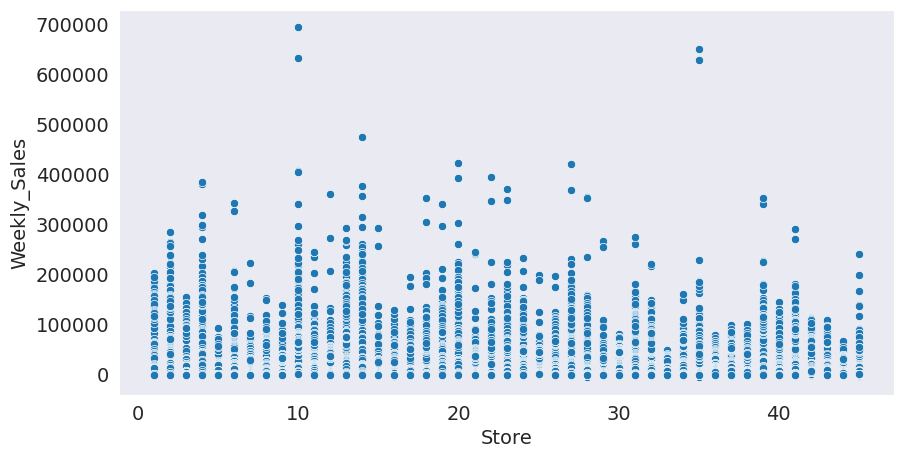

In [47]:
sns.scatterplot(data = merge_train_df, x = 'Store', y='Weekly_Sales');

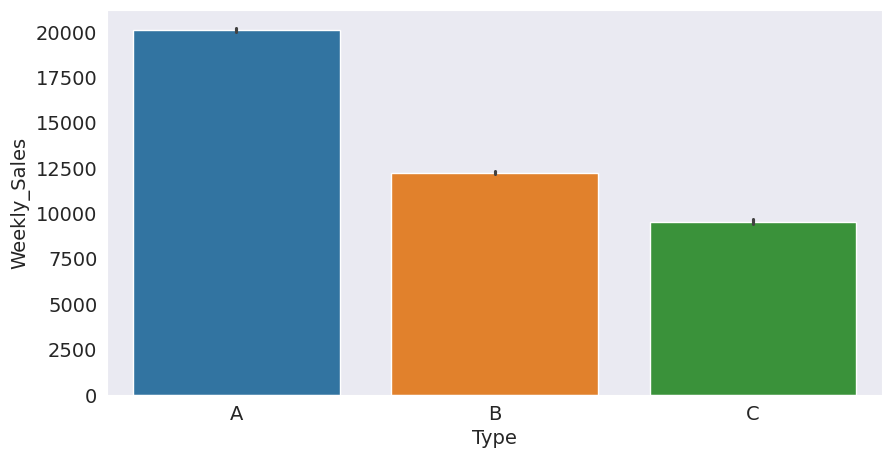

In [48]:
sns.barplot(merge_train_df, x='Type', y = 'Weekly_Sales', hue = 'Type');

In [49]:
merge_train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Day', 'WeekofYear',
       'Month', 'Year'],
      dtype='object')

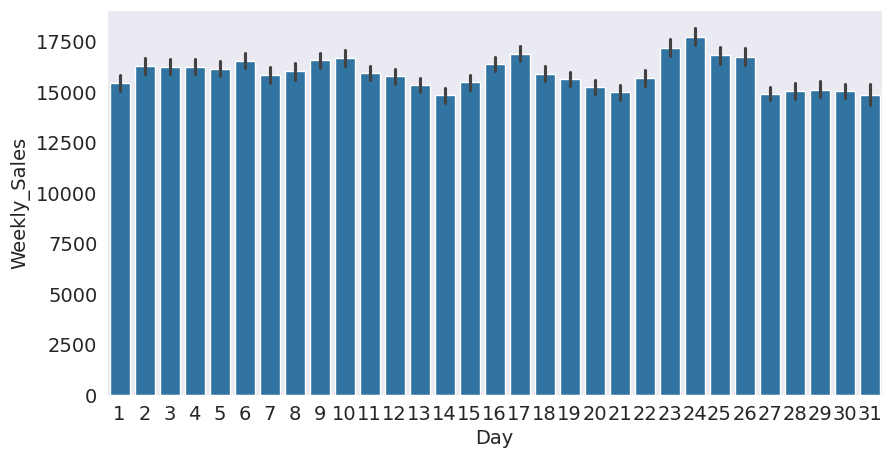

In [50]:
sns.barplot(merge_train_df, x = 'Day', y = 'Weekly_Sales');

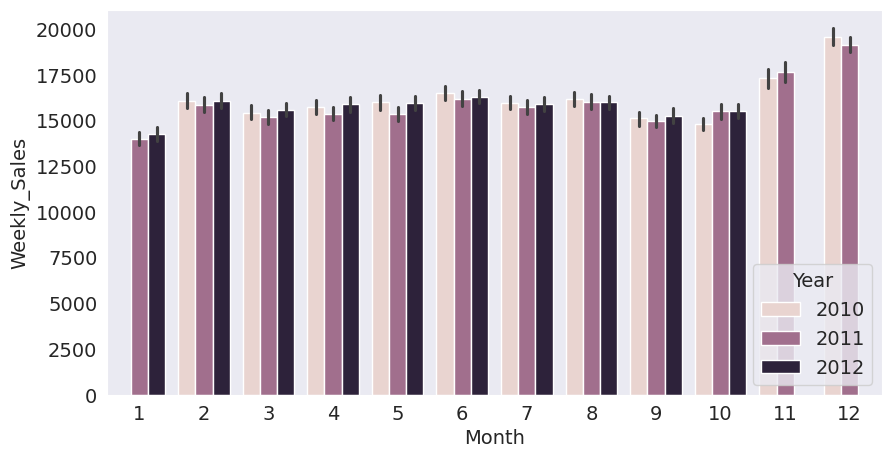

In [51]:
sns.barplot(merge_train_df, x = "Month", y = 'Weekly_Sales', hue = 'Year');

###4. Feature engeneering

In [52]:
# The model correlition
merge_train_df.corr(numeric_only = True)['Weekly_Sales'].sort_values(ascending = False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.243828
Dept,0.148032
MarkDown5,0.090362
MarkDown1,0.085251
MarkDown3,0.060385
MarkDown4,0.045414
Month,0.028409
WeekofYear,0.027673
MarkDown2,0.024130


In [53]:
# The holiday features
def create_holiday_features(df):
  df['BlackFriday_Week'] = np.where(np.isin(df.WeekofYear, np.array([47,48])) ,1,0)
  df['SuperBowl_Week'] = np.where(np.isin(df.WeekofYear, np.array([5,6])), 1,0)
  df['Chrismass'] = np.where(np.isin(df['WeekofYear'], np.array([49,50,51])), 1,0)
  return df

In [54]:
create_holiday_features(merge_train_df)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year,BlackFriday_Week,SuperBowl_Week,Chrismass
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,NaN,211.096358,8.106,5,5,2,2010,0,1,0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,NaN,211.242170,8.106,12,6,2,2010,0,1,0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,NaN,211.289143,8.106,19,7,2,2010,0,0,0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,...,NaN,211.319643,8.106,26,8,2,2010,0,0,0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,...,NaN,211.350143,8.106,5,9,3,2010,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,...,3288.25,192.013558,8.684,28,39,9,2012,0,0,0
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,...,2340.01,192.170412,8.667,5,40,10,2012,0,0,0
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,...,3990.54,192.327265,8.667,12,41,10,2012,0,0,0
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,...,1537.49,192.330854,8.667,19,42,10,2012,0,0,0


In [55]:
create_holiday_features(merge_test_df)

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year,BlackFriday_Week,SuperBowl_Week,Chrismass
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,...,2737.42,223.462779,6.573,2,44,11,2012,0,0,0
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,...,6154.16,223.481307,6.573,9,45,11,2012,0,0,0
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,...,6612.69,223.512911,6.573,16,46,11,2012,0,0,0
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,...,303.32,223.561947,6.573,23,47,11,2012,1,0,0
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,...,6966.34,223.610984,6.573,30,48,11,2012,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,...,3169.69,NaN,NaN,28,26,6,2013,0,0,0
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,...,1514.93,NaN,NaN,5,27,7,2013,0,0,0
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,...,2150.36,NaN,NaN,12,28,7,2013,0,0,0
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,...,1059.46,NaN,NaN,19,29,7,2013,0,0,0


In [56]:
merge_train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,MarkDown5,CPI,Unemployment,Day,WeekofYear,Month,Year,BlackFriday_Week,SuperBowl_Week,Chrismass
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,NaN,211.096358,8.106,5,5,2,2010,0,1,0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,NaN,211.242170,8.106,12,6,2,2010,0,1,0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,NaN,211.289143,8.106,19,7,2,2010,0,0,0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,...,NaN,211.319643,8.106,26,8,2,2010,0,0,0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,...,NaN,211.350143,8.106,5,9,3,2010,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,...,3288.25,192.013558,8.684,28,39,9,2012,0,0,0
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,...,2340.01,192.170412,8.667,5,40,10,2012,0,0,0
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,...,3990.54,192.327265,8.667,12,41,10,2012,0,0,0
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,...,1537.49,192.330854,8.667,19,42,10,2012,0,0,0


In [57]:
# The Markdown features
def create_markdown(df):
  markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
  #has_markdown = ~df[markdown_cols].isna()
  df['has_markdown_col'] = df[markdown_cols].prod(axis=1)
  df['total_markdown'] = df[markdown_cols].sum(axis = 1)

  for col in markdown_cols:
    df['has_'+col] = np.where(np.isnan(df[col]), 0,1)
    df['pct_'+col] = np.where(np.isnan(df[col]), 0, df[col]/df['total_markdown'])
  return df

In [58]:
create_markdown(merge_train_df)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,has_MarkDown1,pct_MarkDown1,has_MarkDown2,pct_MarkDown2,has_MarkDown3,pct_MarkDown3,has_MarkDown4,pct_MarkDown4,has_MarkDown5,pct_MarkDown5
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,...,1,0.481264,1,0.002180,1,0.000158,1,0.169097,1,0.347301
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,...,1,0.522491,0,0.000000,1,0.001948,1,0.233298,1,0.242262
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,...,1,0.298485,0,0.000000,1,0.001204,1,0.091443,1,0.608868
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,...,1,0.503217,0,0.000000,1,0.000799,1,0.109916,1,0.386069


In [59]:
create_markdown(merge_test_df)

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown1,pct_MarkDown1,has_MarkDown2,pct_MarkDown2,has_MarkDown3,pct_MarkDown3,has_MarkDown4,pct_MarkDown4,has_MarkDown5,pct_MarkDown5
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,...,1,0.368899,1,0.280647,1,0.002771,1,0.198443,1,0.149241
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,...,1,0.445563,1,0.131504,1,0.001571,1,0.181278,1,0.240083
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,...,1,0.543574,1,0.016375,1,0.005818,1,0.063524,1,0.370708
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,...,1,0.011579,1,0.000055,1,0.981641,1,0.002751,1,0.003975
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,...,1,0.183375,0,0.000000,1,0.286118,1,0.011224,1,0.519284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,...,1,0.423278,1,0.085230,1,0.000262,1,0.214159,1,0.277071
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,...,1,0.472130,1,0.117823,1,0.030266,1,0.301102,1,0.078680
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,...,1,0.440784,1,0.212523,1,0.009970,1,0.086628,1,0.250095
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,...,1,0.525533,1,0.185809,1,0.036235,1,0.064416,1,0.188007


In [60]:
# Dept rank
dept_rank = merge_train_df.groupby('Dept', as_index = False).agg(mean_dept_sales = ('Weekly_Sales', lambda x:x.mean()))
dept_rank['Dept_rank'] = dept_rank['mean_dept_sales'].rank(ascending = False).astype(int)
dept_rank.sort_values('Dept_rank', ascending = True, inplace = True)
# Store rank
store_rank = merge_train_df.groupby('Store', as_index = False).agg(mean_store_sales = ('Weekly_Sales', lambda x:x.mean()))
store_rank['Store_rank'] = store_rank['mean_store_sales'].rank(ascending = False).astype(int)
store_rank.sort_values('Store_rank', ascending = True, inplace = True)

In [61]:
def create_rank_features(df):
  df = pd.merge(df, dept_rank, on='Dept', how = 'left')
  df = pd.merge(df, store_rank, on='Store', how = 'left')
  return df

In [62]:
merge_train_df = create_rank_features(merge_train_df)
merge_train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,has_MarkDown3,pct_MarkDown3,has_MarkDown4,pct_MarkDown4,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,0,0.000000,0,0.000000,0,0.000000,19213.485088,21,21710.543621,9
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,0,0.000000,0,0.000000,0,0.000000,19213.485088,21,21710.543621,9
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,0,0.000000,0,0.000000,0,0.000000,19213.485088,21,21710.543621,9
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,...,0,0.000000,0,0.000000,0,0.000000,19213.485088,21,21710.543621,9
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,...,0,0.000000,0,0.000000,0,0.000000,19213.485088,21,21710.543621,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,...,1,0.000158,1,0.169097,1,0.347301,6824.694889,44,11662.897315,29
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,...,1,0.001948,1,0.233298,1,0.242262,6824.694889,44,11662.897315,29
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,...,1,0.001204,1,0.091443,1,0.608868,6824.694889,44,11662.897315,29
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,...,1,0.000799,1,0.109916,1,0.386069,6824.694889,44,11662.897315,29


In [63]:
merge_test_df = create_rank_features(merge_test_df)
merge_test_df

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown3,pct_MarkDown3,has_MarkDown4,pct_MarkDown4,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,...,1,0.002771,1,0.198443,1,0.149241,19213.485088,21,21710.543621,9
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,...,1,0.001571,1,0.181278,1,0.240083,19213.485088,21,21710.543621,9
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,...,1,0.005818,1,0.063524,1,0.370708,19213.485088,21,21710.543621,9
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,...,1,0.981641,1,0.002751,1,0.003975,19213.485088,21,21710.543621,9
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,...,1,0.286118,1,0.011224,1,0.519284,19213.485088,21,21710.543621,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,...,1,0.000262,1,0.214159,1,0.277071,6824.694889,44,11662.897315,29
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,...,1,0.030266,1,0.301102,1,0.078680,6824.694889,44,11662.897315,29
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,...,1,0.009970,1,0.086628,1,0.250095,6824.694889,44,11662.897315,29
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,...,1,0.036235,1,0.064416,1,0.188007,6824.694889,44,11662.897315,29


In [64]:
merge_train_df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending = False).index

Index([92, 95, 38, 72, 65, 90, 40,  2, 91, 94, 13,  8, 93,  4,  7, 23, 79,  5,
        9, 46,  1, 10, 34, 81, 82, 96, 14, 11, 97, 16, 74, 87, 80,  3, 22, 55,
       17, 25, 49, 26, 67, 18, 32, 98, 33, 24, 71, 29, 20, 42, 21,  6, 44, 12,
       30, 56, 58, 83, 37, 35, 50, 31, 85, 36, 41, 52, 19, 27, 48, 59, 28, 99,
       60, 77, 54, 45, 51, 39, 78, 43, 47],
      dtype='int64', name='Dept')

In [65]:
merge_train_df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending = False).index

Index([20,  4, 14, 13,  2, 10, 27,  6,  1, 39, 19, 23, 31, 11, 24, 28, 41, 32,
       18, 22, 12, 26, 35, 40, 34, 43,  8, 17, 45, 42, 21, 25, 37, 15,  9, 30,
       36,  7, 29, 16, 38,  3, 44, 33,  5],
      dtype='int64', name='Store')

In [66]:
def top_bottom_sales(df):
  df['Top_Stores'] = np.where(np.isin(df['Store'], np.array([20,  4, 14, 13,  2, 10, 27,  6,  1, 39,])), 1,0)

  df['Botton_Stores'] = np.where(np.isin(df['Store'], np.array([9, 30, 36,  7, 29, 16, 38,  3, 44, 33,  5])), 1,0)

  df['Top_Dept'] = np.where(np.isin(df['Dept'], np.array([92, 95, 38, 72, 65, 90, 40,  2, 91, 94])),1,0)
  df['Botton_Depth'] = np.where(np.isin(df['Dept'], np.array([99,60, 77, 54, 45, 51, 39, 78, 43, 47])),1,0)
  return df

In [67]:
top_bottom_sales(merge_train_df)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,...,1,0.347301,6824.694889,44,11662.897315,29,0,0,0,0
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,...,1,0.242262,6824.694889,44,11662.897315,29,0,0,0,0
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,...,1,0.608868,6824.694889,44,11662.897315,29,0,0,0,0
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,...,1,0.386069,6824.694889,44,11662.897315,29,0,0,0,0


In [68]:
top_bottom_sales(merge_test_df)

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,...,1,0.149241,19213.485088,21,21710.543621,9,1,0,0,0
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,...,1,0.240083,19213.485088,21,21710.543621,9,1,0,0,0
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,...,1,0.370708,19213.485088,21,21710.543621,9,1,0,0,0
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,...,1,0.003975,19213.485088,21,21710.543621,9,1,0,0,0
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,...,1,0.519284,19213.485088,21,21710.543621,9,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,...,1,0.277071,6824.694889,44,11662.897315,29,0,0,0,0
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,...,1,0.078680,6824.694889,44,11662.897315,29,0,0,0,0
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,...,1,0.250095,6824.694889,44,11662.897315,29,0,0,0,0
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,...,1,0.188007,6824.694889,44,11662.897315,29,0,0,0,0


##2. Data preparation

In [69]:
# Sort dataset by Date, Store and Dept
merge_train_df = merge_train_df.sort_values(['Date', 'Store', 'Dept'])

In [70]:
merge_train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,...,0,0.000000,19213.485088,21,21710.543621,9,1,0,0,0
143,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,NaN,...,0,0.000000,43607.020113,8,21710.543621,9,1,0,1,0
286,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,NaN,...,0,0.000000,11793.698516,34,21710.543621,9,1,0,0,0
429,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,NaN,...,0,0.000000,25974.630238,14,21710.543621,9,1,0,0,0
572,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,NaN,...,0,0.000000,21365.583515,18,21710.543621,9,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,False,B,118221,58.85,3.882,4018.91,...,1,0.163577,27008.060746,13,11662.897315,29,0,0,0,0
421146,45,94,2012-10-26,5203.31,False,B,118221,58.85,3.882,4018.91,...,1,0.163577,33405.883963,10,11662.897315,29,0,0,1,0
421289,45,95,2012-10-26,56017.47,False,B,118221,58.85,3.882,4018.91,...,1,0.163577,69824.423080,2,11662.897315,29,0,0,1,0
421434,45,97,2012-10-26,6817.48,False,B,118221,58.85,3.882,4018.91,...,1,0.163577,14255.576919,29,11662.897315,29,0,0,0,0


In [71]:
merge_train_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,has_MarkDown5,pct_MarkDown5,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth
240480,25,26,2011-11-18,3893.81,False,B,128107,46.41,3.530,6165.27,...,1,0.355159,7649.417947,40,10308.157810,32,0,0,0,0
100342,11,20,2010-03-26,8311.70,False,A,207499,58.09,2.732,NaN,...,0,0.000000,5528.787319,49,19276.762751,14,0,0,0,0
331893,35,8,2012-08-24,17114.60,False,B,103681,72.93,3.834,5726.77,...,1,0.271068,30191.263517,12,13803.596986,23,0,0,0,0
72903,8,31,2010-07-02,907.22,False,A,155078,74.78,2.669,NaN,...,0,0.000000,2339.440287,62,13133.014768,27,0,0,0,0
357979,38,52,2012-05-25,5.88,False,C,39690,83.84,4.293,452.90,...,1,0.786362,1928.356252,66,7492.478460,41,0,1,0,0


### 1. Select input an target cols

In [72]:
merge_train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Day', 'WeekofYear',
       'Month', 'Year', 'BlackFriday_Week', 'SuperBowl_Week', 'Chrismass',
       'has_markdown_col', 'total_markdown', 'has_MarkDown1', 'pct_MarkDown1',
       'has_MarkDown2', 'pct_MarkDown2', 'has_MarkDown3', 'pct_MarkDown3',
       'has_MarkDown4', 'pct_MarkDown4', 'has_MarkDown5', 'pct_MarkDown5',
       'mean_dept_sales', 'Dept_rank', 'mean_store_sales', 'Store_rank',
       'Top_Stores', 'Botton_Stores', 'Top_Dept', 'Botton_Depth'],
      dtype='object')

In [73]:
# Set up the input cols and the target col
input_cols = ['Store', 'Dept', 'Date', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Day', 'WeekofYear',
       'Month', 'Year', 'BlackFriday_Week', 'SuperBowl_Week', 'Chrismass',
       'has_markdown_col', 'total_markdown', 'has_MarkDown1', 'pct_MarkDown1',
       'has_MarkDown2', 'pct_MarkDown2', 'has_MarkDown3', 'pct_MarkDown3',
       'has_MarkDown4', 'pct_MarkDown4', 'has_MarkDown5', 'pct_MarkDown5',
       'Top_Stores', 'Botton_Stores', 'Top_Dept', 'Botton_Depth',
       'mean_dept_sales', 'Dept_rank', 'mean_store_sales', 'Store_rank']
target_col = 'Weekly_Sales'

###2. Train, Val and Test sets


In [74]:
from sklearn.model_selection import train_test_split
# split_data
train_inputs, val_inputs, train_target, val_target = train_test_split(merge_train_df[input_cols], merge_train_df[target_col], test_size = 0.2, random_state = 42)


In [75]:
train_inputs

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown5,pct_MarkDown5,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
104516,11,56,2010-12-31,True,A,207499,55.03,2.943,NaN,NaN,...,0,0.000000,0,0,0,0,3833.706211,56,19276.762751,14
154760,16,59,2011-12-23,False,B,57197,20.79,3.173,485.00,0.18,...,1,0.495838,0,1,0,0,694.463564,70,7863.224124,40
340733,36,4,2010-06-04,False,A,39910,79.93,2.664,NaN,NaN,...,0,0.000000,0,1,0,0,25974.630238,14,8584.412563,37
144779,15,56,2011-06-03,False,B,123737,69.80,4.069,NaN,NaN,...,0,0.000000,0,0,0,0,3833.706211,56,9002.493073,34
264648,27,78,2011-08-12,False,A,204184,76.67,3.995,NaN,NaN,...,0,0.000000,1,0,0,1,7.296638,79,24826.984536,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121815,13,31,2011-10-14,False,A,219622,51.74,3.567,NaN,NaN,...,0,0.000000,1,0,0,0,2339.440287,62,27355.136891,4
70745,8,14,2012-06-22,False,A,155078,78.85,3.346,5146.44,124.95,...,1,0.371803,0,0,0,0,14870.966037,27,13133.014768,27
15840,2,42,2010-12-17,False,A,202307,47.55,2.869,NaN,NaN,...,0,0.000000,1,0,0,0,5189.703417,50,26898.070031,5
47036,5,74,2011-01-21,False,B,34875,45.41,3.016,NaN,NaN,...,0,0.000000,0,1,0,0,13807.462764,31,5053.415813,45


In [76]:
val_inputs

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown5,pct_MarkDown5,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
314018,32,99,2011-11-11,False,A,203007,38.10,3.505,21104.84,7842.47,...,1,0.114317,0,0,0,1,415.487065,72,16351.621855,18
93488,10,46,2011-04-01,False,B,126512,67.64,3.772,NaN,NaN,...,0,0.000000,1,0,0,0,19944.741483,20,26332.303819,6
95889,10,80,2012-05-25,False,B,126512,86.03,4.127,7786.58,NaN,...,1,0.239631,1,0,0,0,12183.680224,33,26332.303819,6
331855,35,8,2011-12-02,False,B,103681,50.55,3.452,5051.87,NaN,...,1,0.686890,0,0,0,0,30191.263517,12,13803.596986,23
175671,18,83,2010-11-26,True,B,120653,40.81,3.070,NaN,NaN,...,0,0.000000,0,0,0,0,3383.349838,58,15733.313136,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46841,5,71,2012-10-19,False,B,34875,69.17,3.594,908.91,NaN,...,1,0.438549,0,1,0,0,5722.927649,47,5053.415813,45
339701,35,93,2011-05-06,False,B,103681,56.48,4.046,NaN,NaN,...,0,0.000000,0,0,0,0,27008.060746,13,13803.596986,23
275453,28,83,2012-05-04,False,A,206302,76.03,4.171,16196.98,NaN,...,1,0.298859,0,0,0,0,3383.349838,58,18714.889803,16
58660,6,96,2012-07-27,False,A,202505,85.78,3.407,7017.60,203.26,...,1,0.120487,1,0,0,0,15210.942761,26,21913.243624,8


In [77]:
train_target

,Weekly_Sales
104516,629.68
154760,460.20
340733,11705.49
144779,14841.24
264648,20.00
...,...
121815,2845.40
70745,8159.81
15840,8036.41
47036,2347.13


In [78]:
val_target

,Weekly_Sales
314018,25.00
93488,56292.49
95889,293.07
331855,17460.49
175671,842.68
...,...
46841,252.25
339701,1584.00
275453,10166.57
58660,34301.00


In [79]:
test_inputs = merge_test_df[input_cols]

In [80]:
test_inputs

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown5,pct_MarkDown5,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,...,1,0.149241,1,0,0,0,19213.485088,21,21710.543621,9
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,...,1,0.240083,1,0,0,0,19213.485088,21,21710.543621,9
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,...,1,0.370708,1,0,0,0,19213.485088,21,21710.543621,9
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,...,1,0.003975,1,0,0,0,19213.485088,21,21710.543621,9
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,...,1,0.519284,1,0,0,0,19213.485088,21,21710.543621,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,B,118221,76.05,3.639,4842.29,975.03,...,1,0.277071,0,0,0,0,6824.694889,44,11662.897315,29
115060,45,98,2013-07-05,False,B,118221,77.50,3.614,9090.48,2268.58,...,1,0.078680,0,0,0,0,6824.694889,44,11662.897315,29
115061,45,98,2013-07-12,False,B,118221,79.37,3.614,3789.94,1827.31,...,1,0.250095,0,0,0,0,6824.694889,44,11662.897315,29
115062,45,98,2013-07-19,False,B,118221,82.84,3.737,2961.49,1047.07,...,1,0.188007,0,0,0,0,6824.694889,44,11662.897315,29


### 3. Select numerical and categorical columns

In [81]:
# Set up the numeric cols and the categorical_cols
numeric_cols = ['Store', 'Dept', 'Size', 'Temperature',
                'Fuel_Price', 'CPI', 'Unemployment', 'Day', 'WeekofYear', 'Month',
                'has_markdown_col', 'total_markdown', 'pct_MarkDown1',
                'pct_MarkDown2', 'pct_MarkDown3','pct_MarkDown4', 'pct_MarkDown5',
                'mean_dept_sales', 'Dept_rank', 'mean_store_sales', 'Store_rank']
categorical_cols = ['IsHoliday', 'Type', 'Year', 'BlackFriday_Week', 'SuperBowl_Week', 'Chrismass',
                    'has_MarkDown1',  'has_MarkDown2', 'has_MarkDown3', 'has_MarkDown4', 'has_MarkDown5',
                    'Top_Stores', 'Botton_Stores', 'Top_Dept',
                    'Botton_Depth',]

In [82]:
len(numeric_cols), len(categorical_cols)

(21, 15)

### 4. Impute the missing values

In [83]:
# Impute mission numeric values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'mean').fit(merge_train_df[numeric_cols])

train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

### 5. Scale the numerical columns

In [84]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
scaler = MinMaxScaler().fit(merge_train_df[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [85]:
test_inputs

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,has_MarkDown5,pct_MarkDown5,Top_Stores,Botton_Stores,Top_Dept,Botton_Depth,mean_dept_sales,Dept_rank,mean_store_sales,Store_rank
0,0.0,0.000000,2012-11-02,False,A,0.630267,0.561448,0.457916,6766.44,5147.70,...,1,0.149126,1,0,0,0,0.255558,0.2500,0.681137,0.181818
1,0.0,0.000000,2012-11-09,False,A,0.630267,0.619374,0.421844,11421.32,3370.89,...,1,0.239898,1,0,0,0,0.255558,0.2500,0.681137,0.181818
2,0.0,0.000000,2012-11-16,False,A,0.630267,0.537965,0.390782,9696.28,292.10,...,1,0.370422,1,0,0,0,0.255558,0.2500,0.681137,0.181818
3,0.0,0.000000,2012-11-23,True,A,0.630267,0.570352,0.370240,883.59,4.17,...,1,0.003972,1,0,0,0,0.255558,0.2500,0.681137,0.181818
4,0.0,0.000000,2012-11-30,False,A,0.630267,0.532290,0.368236,2460.03,NaN,...,1,0.518883,1,0,0,0,0.255558,0.2500,0.681137,0.181818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,1.0,0.989796,2013-06-28,False,B,0.451136,0.764286,0.584669,4842.29,975.03,...,1,0.276858,0,0,0,0,0.090841,0.5375,0.270272,0.636364
115060,1.0,0.989796,2013-07-05,False,B,0.451136,0.778474,0.572144,9090.48,2268.58,...,1,0.078620,0,0,0,0,0.090841,0.5375,0.270272,0.636364
115061,1.0,0.989796,2013-07-12,False,B,0.451136,0.796771,0.572144,3789.94,1827.31,...,1,0.249902,0,0,0,0,0.090841,0.5375,0.270272,0.636364
115062,1.0,0.989796,2013-07-19,False,B,0.451136,0.830724,0.633768,2961.49,1047.07,...,1,0.187862,0,0,0,0,0.090841,0.5375,0.270272,0.636364


### 6.Encoder values

In [86]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore').fit(merge_train_df[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

### 7. Set up the new data columns

In [87]:
train_x = train_inputs[numeric_cols + encoded_cols]
val_x = val_inputs[numeric_cols + encoded_cols]
test_x = test_inputs[numeric_cols + encoded_cols]

In [88]:
train_x

,Store,Dept,Size,Temperature,Fuel_Price,CPI,Unemployment,Day,WeekofYear,Month,...,has_MarkDown5_0,has_MarkDown5_1,Top_Stores_0,Top_Stores_1,Botton_Stores_0,Botton_Stores_1,Top_Dept_0,Top_Dept_1,Botton_Depth_0,Botton_Depth_1
104516,0.227273,0.561224,0.934381,0.558611,0.235972,0.876106,0.353172,1.000000,1.000000,1.000000,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
154760,0.340909,0.591837,0.120825,0.223581,0.351202,0.692974,0.225513,0.733333,0.980392,1.000000,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
340733,0.795455,0.030612,0.027253,0.802250,0.096192,0.829068,0.439429,0.100000,0.411765,0.454545,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
144779,0.318182,0.561224,0.480993,0.703131,0.800100,0.086896,0.362181,0.066667,0.411765,0.454545,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
264648,0.590909,0.785714,0.916437,0.770352,0.763026,0.138600,0.380583,0.366667,0.607843,0.636364,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121815,0.272727,0.306122,1.000000,0.526419,0.548597,0.036638,0.240847,0.433333,0.784314,0.818182,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
70745,0.159091,0.132653,0.650636,0.791683,0.437876,0.981448,0.172513,0.700000,0.470588,0.454545,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
15840,0.022727,0.418367,0.906277,0.485421,0.198898,0.840185,0.410581,0.533333,0.960784,1.000000,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
47036,0.090909,0.744898,0.000000,0.464481,0.272545,0.853188,0.264041,0.666667,0.039216,0.000000,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


##3. Model Training and Evaluating

###1. Train baseline model

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [91]:
# Create the loss function
def rmse(inputs, targets):
  return np.sqrt(mean_squared_error(inputs, targets))

In [92]:
class RegressionMean():
  def fit(self, inputs, targets):
    self.mean = targets.mean()
  def predict(self, inputs):
    return np.full(len(inputs), self.mean)

In [93]:
mean_model = RegressionMean()

In [94]:
mean_model.fit(train_x, train_target)

In [95]:
mean_preds = mean_model.predict(train_x)
mean_preds

array([15998.94833569, 15998.94833569, 15998.94833569, ...,
       15998.94833569, 15998.94833569, 15998.94833569])

In [96]:
rmse(mean_preds, train_target)

np.float64(22726.543181280864)

### 2. Train the linear model

In [97]:
# Create and train model
model_0 = LinearRegression().fit(train_x, train_target)

In [98]:
# Generate Prediction and Probabilities
train_preds = model_0.predict(train_x)
train_rmse = rmse(train_preds, train_target)
train_rmse

np.float64(13236.34526190295)

In [ ]:
def eval_model(model):
  train_preds = model.predict(train_x)
  val_preds = model.predict(val_x)
  train_rmse = rmse(train_preds, train_target)
  val_rmse = rmse(val_preds, val_target)
  return train_rmse, val_rmse, train_preds, val_preds

In [ ]:
eval_model(model_0)

In [ ]:
from sklearn.linear_model import Ridge
model_1 = Ridge(tol = 1e-7).fit(train_x, train_target)

In [103]:
eval_model(model_1)

(np.float64(13236.371517998348),
 np.float64(13350.559357932347),
 array([ 7367.03058247, -1932.37437873, 16569.80790496, ...,
        22704.54086875,  1347.81894463,  7275.41222555]),
 array([ -675.40688796, 31658.72986253, 23936.47561161, ...,
         6194.45995998, 22019.25576741, 13897.57046441]))

### 3. Train the decision tree model

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
tree_model = DecisionTreeRegressor(max_depth = 40, random_state = 42).fit(train_x, train_target)

In [ ]:
eval_model(tree_model)

(np.float64(0.8828808985430093),
 np.float64(4711.008358980772),
 array([  629.68,   460.2 , 11705.49, ...,  8036.41,  2347.13,  6663.75]),
 array([  125.01, 58790.33,   288.2 , ..., 10597.17, 30826.95, 10831.59]))

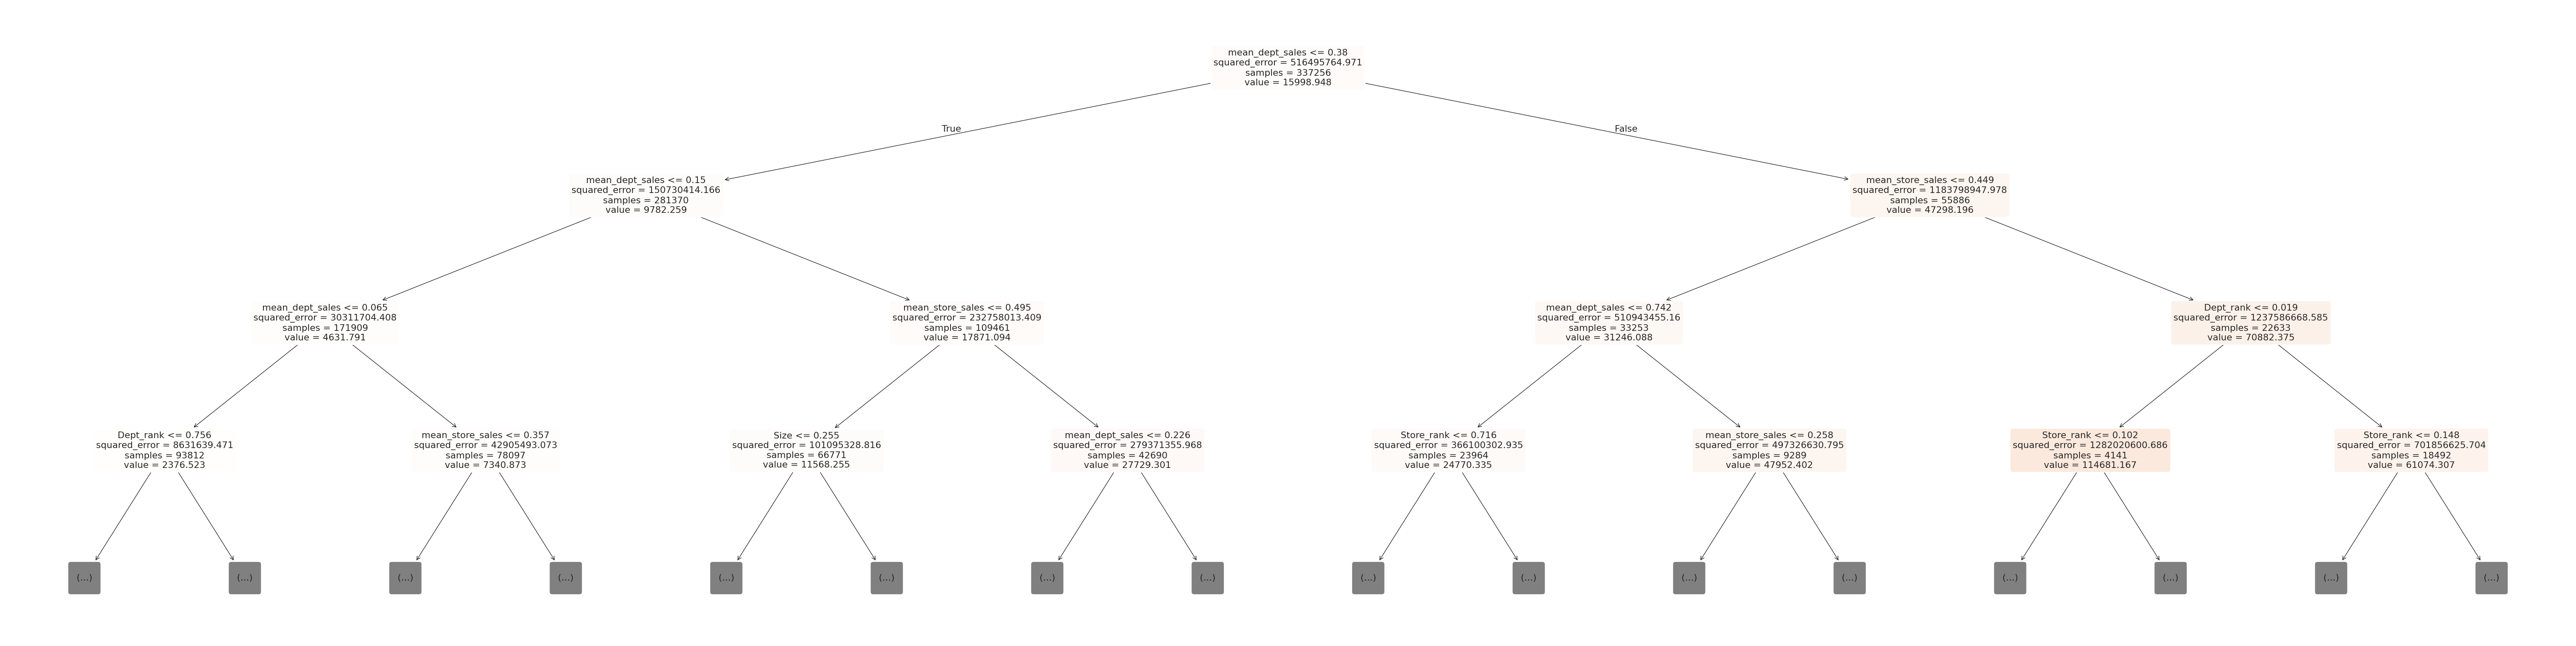

In [ ]:
# Plot the desicion model tree
plt.figure(figsize = (80,20))
plot_tree(tree_model, max_depth = 3, feature_names = train_x.columns, filled = True, rounded = True);

In [104]:
# Create the submission_df and predict the test values
from IPython.display import FileLink
def predict_and_submit(model, inputs, file_name):
  test_preds = model.predict(inputs)
  submission_df = pd.read_csv('data/sampleSubmission.csv')
  submission_df['WeeklySales'] = test_preds
  submission_df.to_csv(file_name, index = None)
  return FileLink(file_name)

In [ ]:
predict_and_submit(tree_model, test_x, 'submission_tree_model.csv')

/content/submission_tree_model.csv

### 4. Train the Random Forest Model

In [155]:
from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor(n_estimators = 100, max_depth = 5, n_jobs = -1, random_state = 42).fit(train_x, train_target)

In [156]:
eval_model(forest_model)

(np.float64(10388.614095662866),
 np.float64(10572.768631542103),
 array([ 2992.98886398,   396.44559866, 13645.828287  , ...,
         8623.3075249 ,  5860.28479351,  8592.2573173 ]),
 array([  396.44559866, 42160.09965766, 25078.55678837, ...,
         2992.98886398, 25078.55678837, 14191.34249653]))

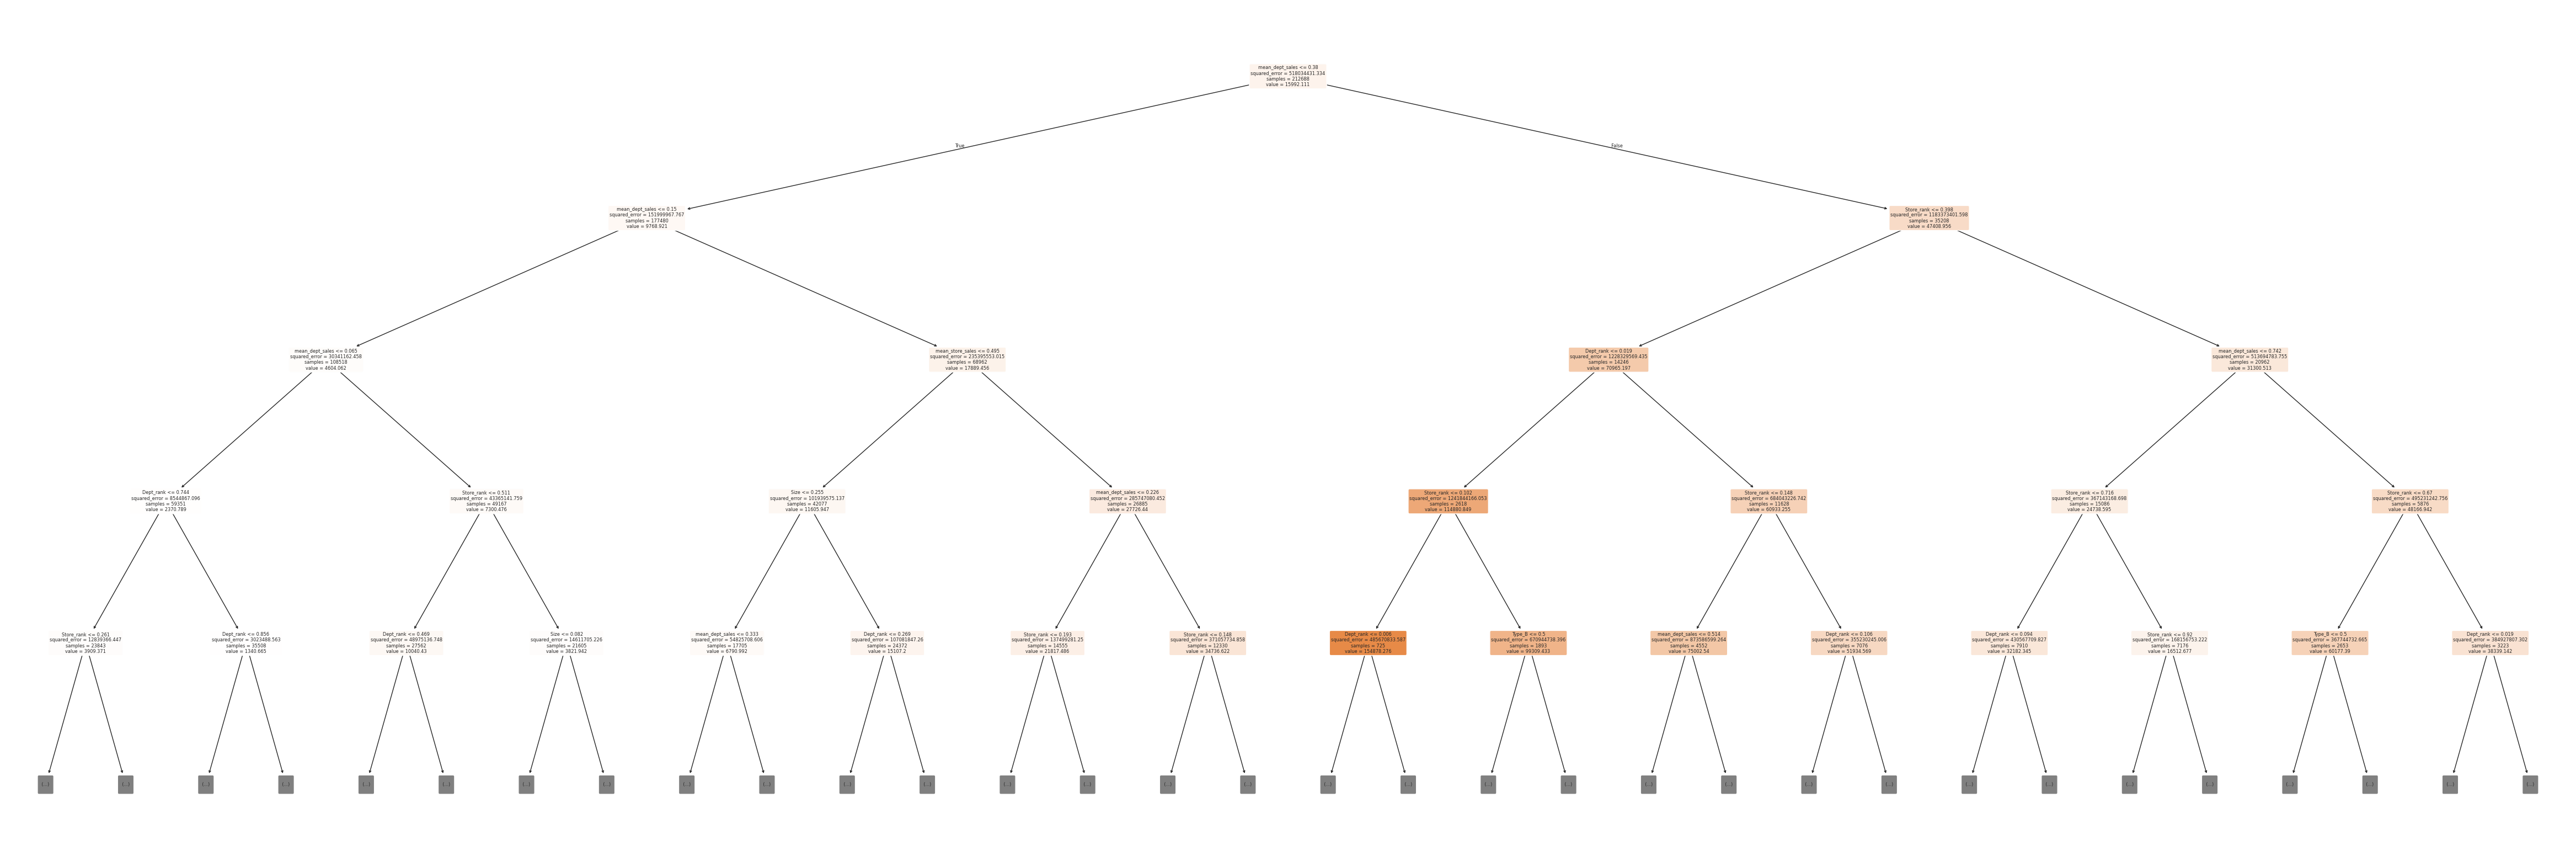

In [ ]:
# Plot the random forest tree
from sklearn.tree import plot_tree
plt.figure(figsize = (60,20))
plot_tree(forest_model.estimators_[3], max_depth = 4, feature_names = train_x.columns, filled = True, rounded = True);

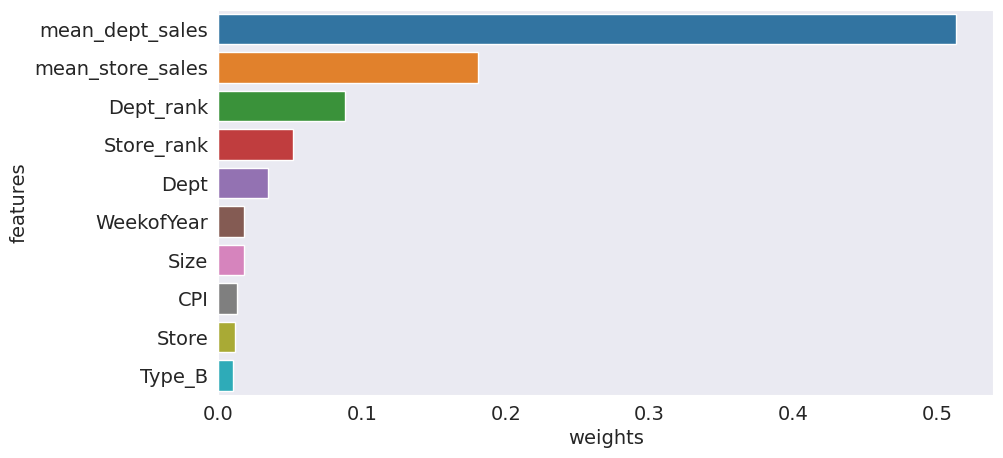

In [ ]:
# Show the feature importances
weights_df = pd.DataFrame({
    'features' : train_x.columns,
    'weights'  : tree_model.feature_importances_
})
sns.barplot(weights_df.sort_values('weights', ascending = False).head(10), x='weights', y='features', hue='features');

In [105]:
def test_params(Class_model, **params):
  model = Class_model(**params).fit(train_x, train_target)
  train_rmse = rmse(model.predict(train_x), train_target)
  val_rmse = rmse(model.predict(val_x), val_target)
  return train_rmse, val_rmse

In [106]:
def test_params_and_plot(Class_model, param_name, param_values, **other_params):
  train_error, val_error = [],[]
  for value in param_values:
    params = dict(**other_params)
    params[param_name] = value
    train_rmse, val_rmse = test_params(Class_model, **params)
    train_error.append(train_rmse)
    val_error.append(val_rmse)
  plt.title('Overfitting Curve')
  plt.plot(param_values, train_error, 'g-o', label = 'train_loss')
  plt.plot(param_values, val_error, 'r-x', label = 'val_loss')
  plt.xlabel('Curve of '+param_name)
  plt.ylabel('Model_loss')
  plt.legend();

In [ ]:
best_params = {'random_state':42,
               'n_jobs':-1}

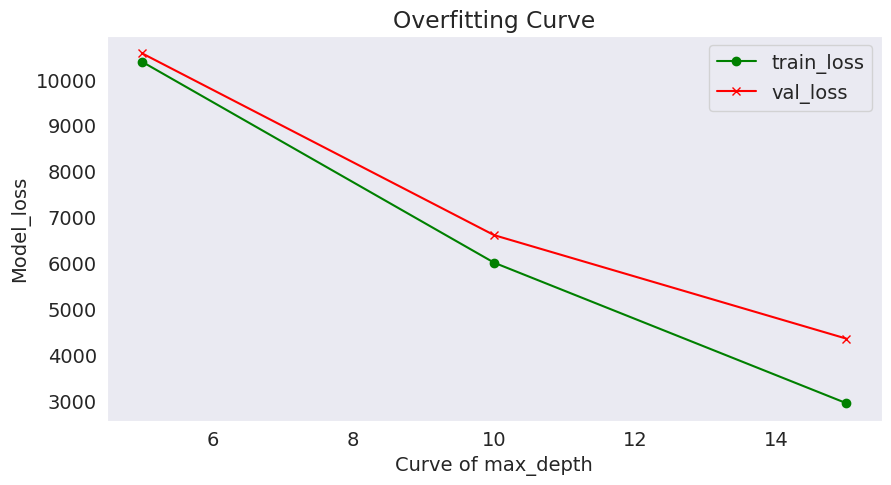

In [ ]:
test_params_and_plot(RandomForestRegressor,'max_depth',[5, 10, 15],**best_params)

### 5. Train the XGB model

In [107]:
from xgboost import XGBRegressor, plot_tree

In [108]:
xgb_model = XGBRegressor(n_jobs = -1, max_depth = 5,n_estimators = 100,
                         random_state = 42).fit(train_x, train_target)

In [109]:
eval_model(xgb_model)

(np.float64(5124.500335526586),
 np.float64(5523.328727126293),
 array([ 2988.1968,  1469.2529, 10852.471 , ..., 11530.4795,  4535.075 ,
         5674.8506], dtype=float32),
 array([-3174.3486, 47811.81  ,  6503.8945, ...,  5920.8623, 26550.387 ,
        10625.073 ], dtype=float32))

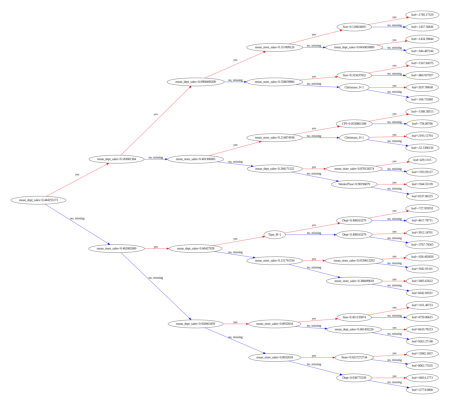

In [110]:
# Plot the xgbregressor tree
plot_tree(xgb_model, tree_idx = 3, rankdir = 'LR');

In [111]:
best_params = {
    'n_jobs':-1,
    'random_state':42
}

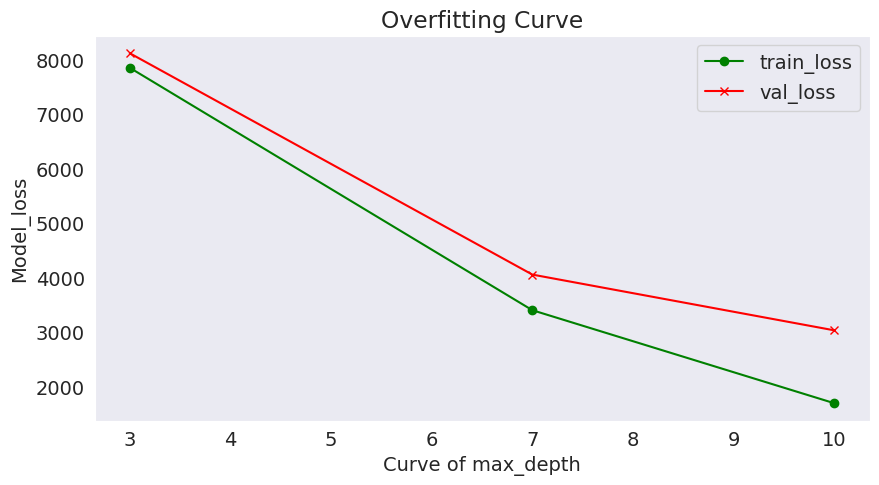

In [ ]:
test_params_and_plot(XGBRegressor, 'max_depth', [3,7,10], **best_params)

In [112]:
best_params['max_depth'] = 5

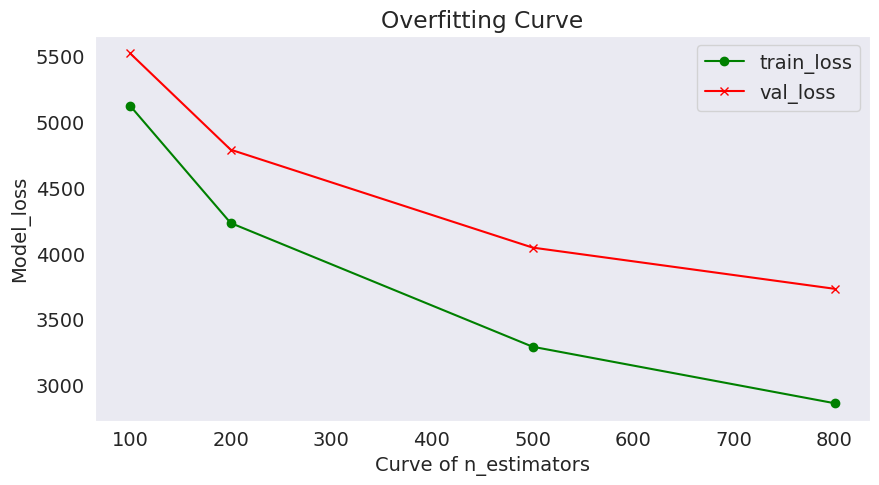

In [113]:
test_params_and_plot(XGBRegressor, 'n_estimators', [100,200, 500,800], **best_params)

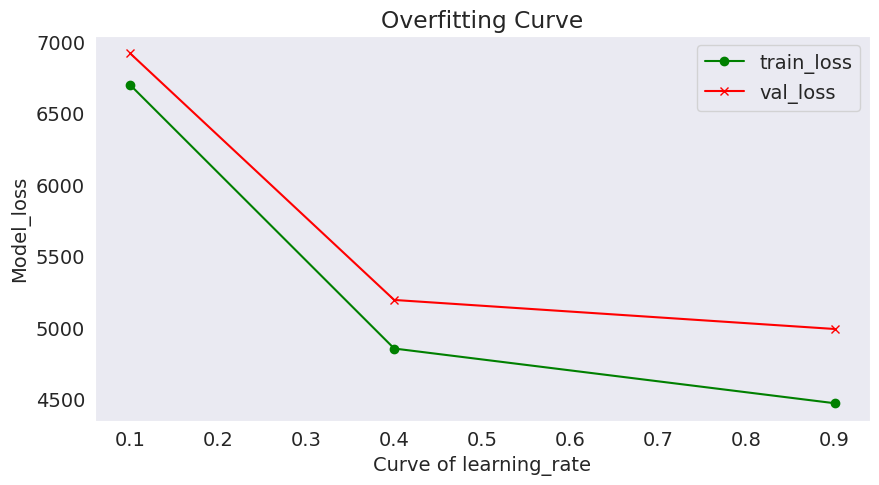

In [114]:
test_params_and_plot(XGBRegressor, 'learning_rate', [0.1,0.4,0.9], **best_params)

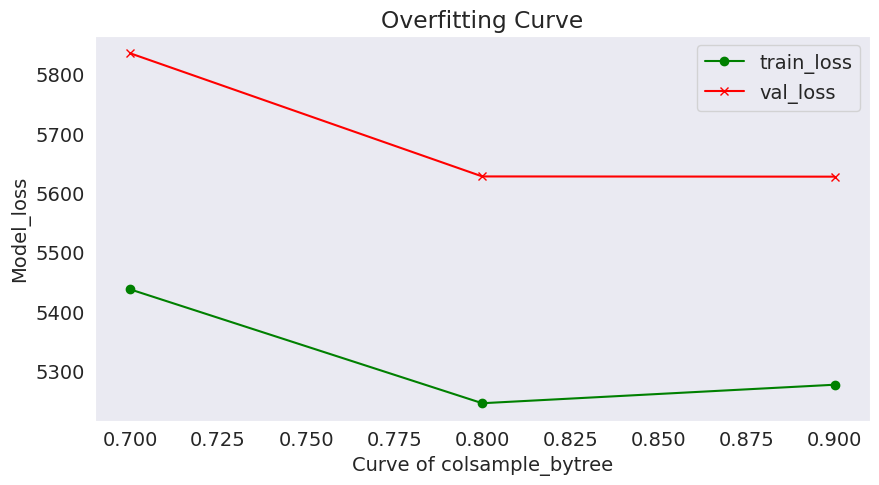

In [116]:
test_params_and_plot(XGBRegressor, 'colsample_bytree', [0.7,0.8,0.9], **best_params)

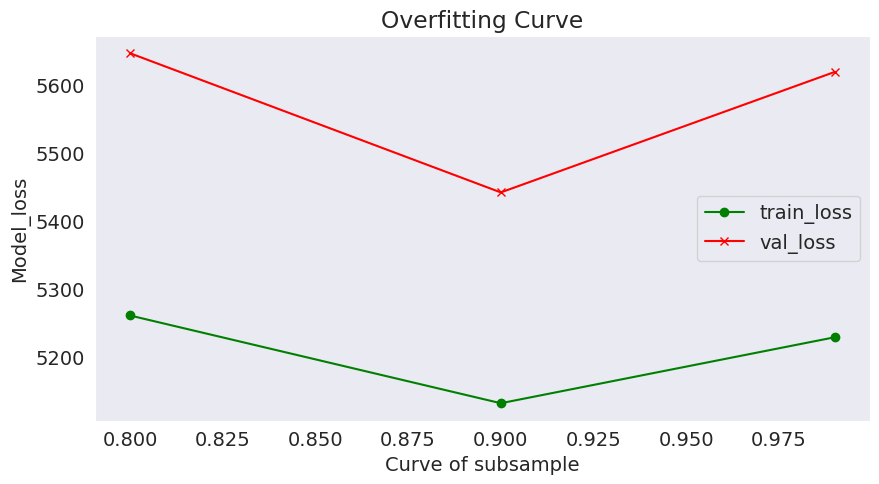

In [119]:
test_params_and_plot(XGBRegressor, 'subsample', [0.8,0.9,0.99], **best_params)

In [115]:
from xgboost import XGBRegressor

In [148]:
xgb_final_model = XGBRegressor(learning_rate = 0.3, n_estimators = 1500, max_depth = 10, n_jobs = -1, random_state = 42).fit(train_x, train_target)

In [149]:
eval_model(xgb_final_model)

(np.float64(207.3443690747036),
 np.float64(2785.727250989049),
 array([  572.98175,   451.79443, 11578.272  , ...,  8227.374  ,
         2466.046  ,  6493.938  ], dtype=float32),
 array([  519.01556, 57502.164  ,  2172.3196 , ...,  9379.899  ,
        30605.809  , 11299.465  ], dtype=float32))

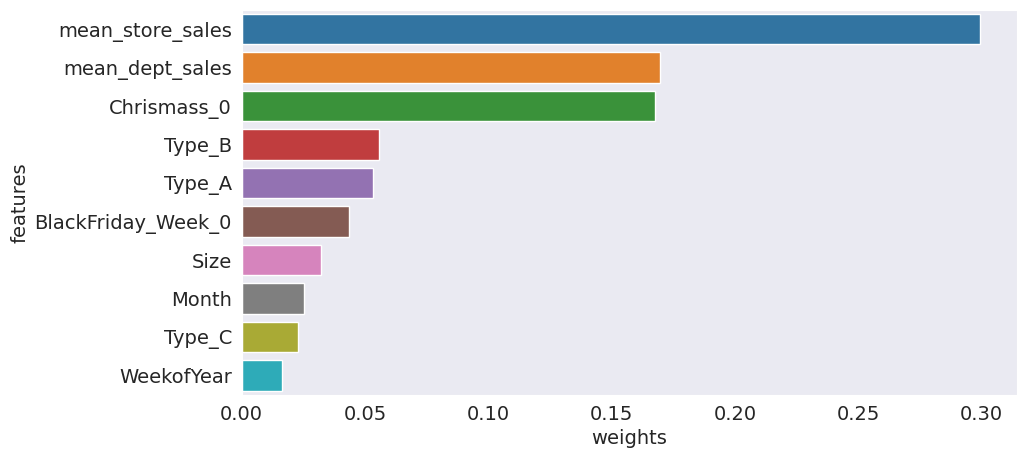

In [151]:
weights_df = pd.DataFrame({
    'features':train_x.columns,
    'weights':xgb_final_model.feature_importances_
})
sns.barplot(weights_df.sort_values("weights", ascending = False).head(10), x='weights', y='features', hue = 'features');

In [153]:
# Download the sample submission and predict the test data
predict_and_submit(model = xgb_final_model, inputs = test_x, file_name = 'xgb_final_model_Samplesubmission.csv')

/content/xgb_final_model_Samplesubmission.csv